--- 표본 추출 분석 결과 (n=50) ---


,Method,Size,Mean (평균),Variance (분산)
0,Population (모집단),244,2.998279,1.906609
1,Simple Random,50,2.643600,1.225091
2,Stratified,50,3.045800,1.603064
3,Systematic,50,2.988800,1.395999


/tmp/ipykernel_297/1735059107.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Mean (평균)', data=results, palette='muted')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51665 (\N{HANGUL 

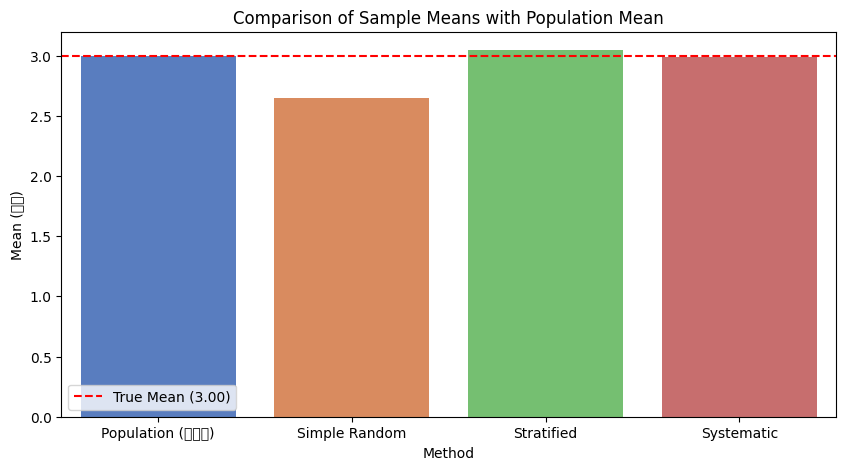

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. 데이터 로드 (모집단)
tips = sns.load_dataset('tips')
pop_mean = tips['tip'].mean()
pop_var = tips['tip'].var(ddof=0)

# 2. 3가지 표본추출방법 (각 n=50)
n_size = 50

# (1) 단순 임의 추출
simple_sample = tips.sample(n=n_size, random_state=42)

# (2) 층화 추출 (성별 기준 비율 유지)
stratified_sample, _ = train_test_split(
    tips, train_size=n_size, stratify=tips['sex'], random_state=42
)

# (3) 계통 추출 (간격 k를 이용)
k = len(tips) // n_size # 약 4의 간격
systematic_sample = tips.iloc[::k][:n_size]

# 3. 결과 비교 데이터프레임
results = pd.DataFrame({
    'Method': ['Population (모집단)', 'Simple Random', 'Stratified', 'Systematic'],
    'Size': [len(tips), len(simple_sample), len(stratified_sample), len(systematic_sample)],
    'Mean (평균)': [pop_mean, simple_sample['tip'].mean(), stratified_sample['tip'].mean(), systematic_sample['tip'].mean()],
    'Variance (분산)': [pop_var, simple_sample['tip'].var(ddof=0), stratified_sample['tip'].var(ddof=0), systematic_sample['tip'].var(ddof=0)]
})

print("--- 표본 추출 분석 결과 (n=50) ---")
display(results)

# 4. 시각화: 평균 비교
plt.figure(figsize=(10, 5))
sns.barplot(x='Method', y='Mean (평균)', data=results, palette='muted')
plt.axhline(pop_mean, color='red', linestyle='--', label=f'True Mean ({pop_mean:.2f})')
plt.title('Comparison of Sample Means with Population Mean')
plt.legend()
plt.show()